## Contextual (local) click embeddings using Word2Vec

In [5]:
from utils.ml import tokenize, load_data, data_dir, evaluate_clustering_model, vectorize
df = load_data(data_dir)
sequences, tokens = tokenize(df)

TOKENIZED DF:
+----+-----+---+-----+-------+----------+--------------------+
|year|month|day|order|country|session ID|            sequence|
+----+-----+---+-----+-------+----------+--------------------+
|2008|    4|  1|    9|     29|         1|[197, 149, 51, 91...|
|2008|    4|  1|   10|     29|         2|[87, 12, 215, 9, ...|
+----+-----+---+-----+-------+----------+--------------------+
only showing top 2 rows
TOKEN INFO: 
+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+---+
|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page| id|
+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+---+
|                     4|                    P51|     9|       5|                1|   28|      2|   3|  0|
|                     4|                    P57|     4|       1|                1|   43|      1|   4|  1|
+----------------------+-----------------

### Word2Vec

In [6]:
melted_sequences = vectorize(sequences)

Word2Vec model not found. Refitting...


+---+----+-----+---+-------+----------+--------------------+
| id|year|month|day|country|session ID|              vector|
+---+----+-----+---+-------+----------+--------------------+
|197|2008|    4|  1|     29|         1|[0.28318807482719...|
|149|2008|    4|  1|     29|         1|[0.28619453310966...|
| 51|2008|    4|  1|     29|         1|[-0.0887719988822...|
| 91|2008|    4|  1|     29|         1|[-0.1072944700717...|
|111|2008|    4|  1|     29|         1|[0.03454396501183...|
+---+----+-----+---+-------+----------+--------------------+
only showing top 5 rows


### Let's try to cluster mean pooling

In [7]:
from pyspark.ml.stat import Summarizer
from pyspark.sql import functions as F
from pyspark.ml.feature import Normalizer
pooled = melted_sequences.groupBy("Session ID").agg(Summarizer.mean(F.col("vector")).alias("context"))
pooled.show(5)
normalized = Normalizer(inputCol="context", outputCol="context_norm").transform(pooled)
normalized.show(5)

+----------+--------------------+
|Session ID|             context|
+----------+--------------------+
|         1|[0.00564688154392...|
|         2|[-0.2188840629532...|
|         3|[-0.1045510439435...|
|         4|[0.11876117158681...|
|         5|[0.29358670115470...|
+----------+--------------------+
only showing top 5 rows
+----------+--------------------+--------------------+
|Session ID|             context|        context_norm|
+----------+--------------------+--------------------+
|         1|[0.00564688154392...|[0.00842646014971...|
|         2|[-0.2188840629532...|[-0.2514489934028...|
|         3|[-0.1045510439435...|[-0.1000907247108...|
|         4|[0.11876117158681...|[0.09004312651518...|
|         5|[0.29358670115470...|[0.18933299234879...|
+----------+--------------------+--------------------+
only showing top 5 rows


In [ ]:
results = {"K-Means": [], "Bisecting KMeans": []}
from pyspark.ml.clustering import BisectingKMeans, KMeans
results["K-Means"].append(evaluate_clustering_model(KMeans(maxIter=30), normalized , range(2, 21), features_col="context_norm", distance = "cosine"))
print("K-Means: done.")
results["Bisecting KMeans"].append(evaluate_clustering_model(BisectingKMeans(maxIter=50), normalized , range(2, 21), features_col="context_norm", distance = "cosine"))
print("Bi-Means: done.")

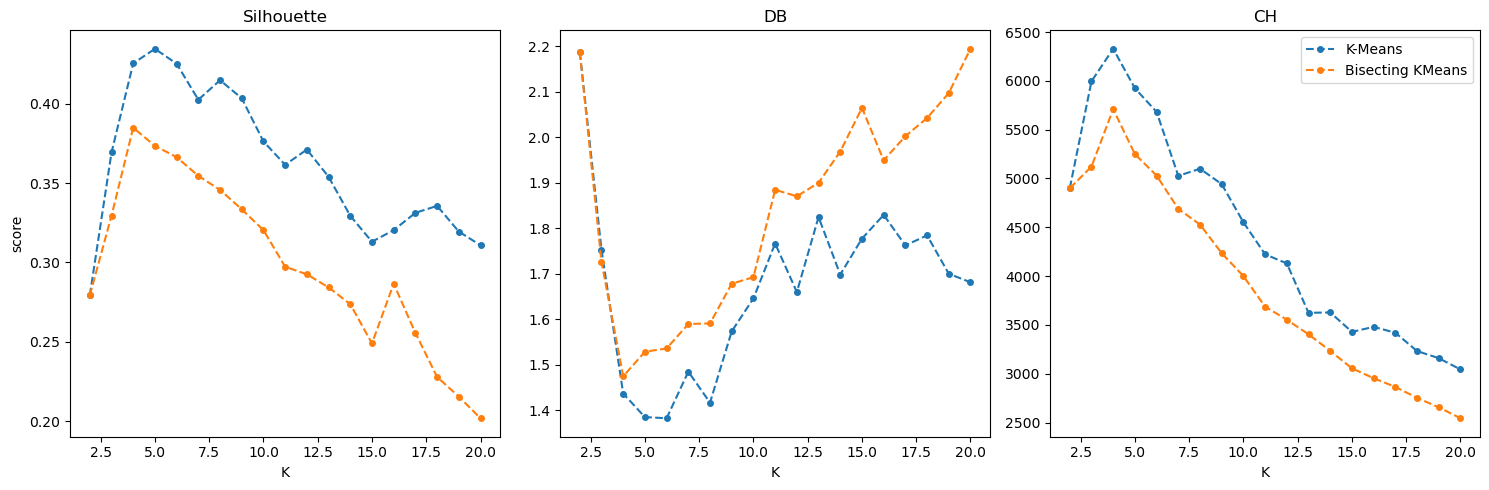

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=False)
models = list(results.keys())
scores = ["Silhouette", "DB", "CH"]
for r in range(1):
    for m in models:
        ax[0].plot(results[m][r]["N_K"], results[m][r]["silouhette"], label= m, linestyle = "--", marker = "o", markersize = 4)
        ax[1].plot(results[m][r]["N_K"], results[m][r]["davies_bouldin"], label= m, linestyle = "--", marker = "o", markersize = 4)
        ax[2].plot(results[m][r]["N_K"], results[m][r]["calinski_harabasz"], label= m, linestyle = "--", marker = "o", markersize = 4)
    for c in range(3):
        ax[c].set_xlabel("K")
        if r == 0:
            ax[c].set_title(scores[c])
        if c == 0:
            ax[c].set_ylabel(f"score")
        if c == 2:
            ax[c].legend()
plt.tight_layout()
plt.show()